In [26]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [27]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train, X_test = X_train / 255.0, X_test / 255.0

X_train = X_train[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print(f"Training image size: {X_train.shape}")
print(f"Training label size: {y_train.shape}")
print(f"Testing image size: {X_test.shape}")

Training image size: (60000, 28, 28, 1)
Training label size: (60000,)
Testing image size: (10000, 28, 28, 1)


In [28]:
datagen = ImageDataGenerator(
    rotation_range=10,        # Slight rotation (pen angle variation)
    width_shift_range=0.1,    # Horizontal shift
    height_shift_range=0.1,   # Vertical shift
    zoom_range=0.1,           # Zoom in/out
    shear_range=0.1,          # Shearing (italic-like distortion)
)

In [29]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [30]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=[lr_scheduler, early_stop]
)

model.save('../models/digit_model.keras')

Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 104s 108ms/step - accuracy: 0.8961 - loss: 0.3359 - val_accuracy: 0.9836 - val_loss: 0.0494 - learning_rate: 0.0010
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 100s 106ms/step - accuracy: 0.9640 - loss: 0.1187 - val_accuracy: 0.9889 - val_loss: 0.0354 - learning_rate: 0.0010
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 135s 144ms/step - accuracy: 0.9725 - loss: 0.0906 - val_accuracy: 0.9894 - val_loss: 0.0329 - learning_rate: 0.0010
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 119s 126ms/step - accuracy: 0.9762 - loss: 0.0801 - val_accuracy: 0.9875 - val_loss: 0.0382 - learning_rate: 0.0010
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 452s 482ms/step - accuracy: 0.9784 - loss: 0.0711 - val_accuracy: 0.9877 - val_loss: 0.0369 - learning_rate: 0.0010
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9797 - loss: 0.0665
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
938/938 ━━━━━━━━━━━━━━━━━━━━ 161s 172ms/step - accuracy:

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


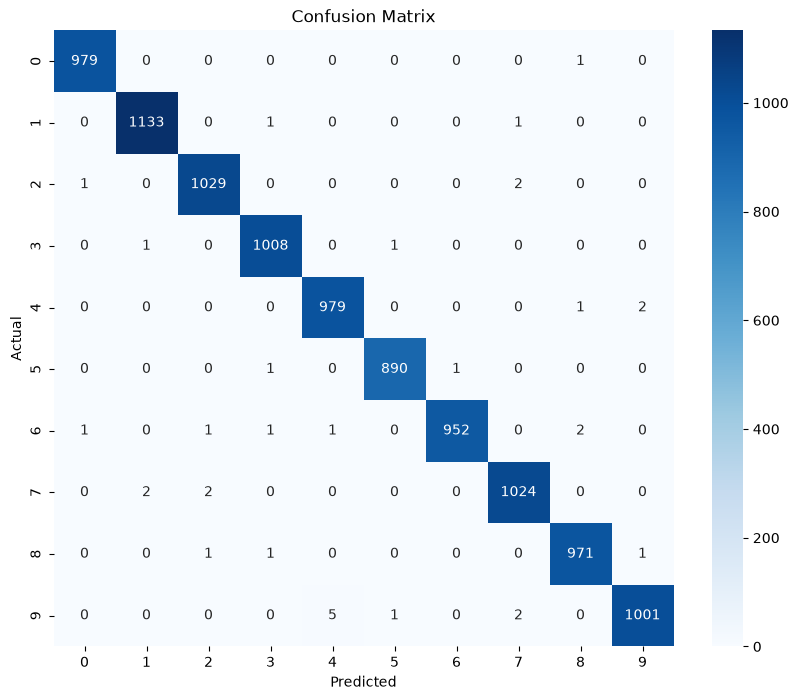

In [31]:
y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()